# Exploración del Global Copper Deposit Dataset

Primer acercamiento al dataset: carga, EDA y baseline con XGBoost para estimar ley de cobre.

## 1. Cargar datos

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("../data/external/Global-copper-deposit-dataset/Global_Copper_Deposit_Main.xlsx")
print(df.shape)
df.columns.tolist()
df.head()

(1487, 20)


,Mindat_id,Mindat_url,Deposit_name,Country,Latitude,Longitude,Deposit_type,Tonnage(Mt),Copper_grade(Cu; %),Molybdenum_grade(Mo; %),Gold_grade(Au; g/t),Silver_grade(Ag; g/t),Lead_grade(Pb; %),Zinc_grade(Zn; %),Nickel_grade(Ni; %),Cobalt_grade(Co; g/t),Max_age(Ma),Min_age(Ma),Mineral_assemblage,Chemical_Elements
0,641.0,Https://www.mindat.org/loc-641.html,Chuquicamata,Chile,-22.289444,-68.901111,Porphyry,21277.0,0.592,0.0400,0.013,5.0,NaN,NaN,NaN,NaN,35.07,31.0,"Albite,Aluminite,Alunite,Alunogen,Amarantite,A...",-Al-Na-Si-O-S-H-K-Fe-Ca-Cu-Cl-C-Ba-I-Mg-Ti-F-M...
1,2120.0,Https://www.mindat.org/loc-2120.html,Calabona,Italy,40.533056,8.334167,Porphyry,189.0,0.070,NaN,NaN,0.5,NaN,NaN,NaN,NaN,34.00,27.0,"Albite,Allophane,Alunite,Anhydrite,Azurite,Bor...",-Al-Na-Si-O-H-K-S-Ca-Cu-C-Fe-Mg-Ti-F-As-Sb-Pb-...
2,2355.0,Https://www.mindat.org/loc-2355.html,La Caridad,Mexico,30.320611,-109.564934,Porphyry,1800.0,0.452,0.0247,NaN,NaN,NaN,NaN,NaN,NaN,54.20,53.4,"Alunite,Anhydrite,Baryte,Bornite,Beryl,Chalcop...",-Al-O-K-S-H-Ca-Ba-Fe-Mg-Si-Ti-F-Cu-Be-As-Mo-Pb...
3,2596.0,Https://www.mindat.org/loc-2596.html,Moldova Noua,Romania,44.737778,21.702500,Porphyry,500.0,0.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.10,65.0,"Aikinite,Allophane,Analcime,Anhydrite,Anthophy...",-Bi-Cu-Pb-S-Al-Si-O-H-Na-Ca-Mg-C-Zn-As-Fe-Ti-K...
4,3326.0,Https://www.mindat.org/loc-3326.html,Christmas,USA,33.058333,-110.745833,Porphyry,48.1,1.100,NaN,0.010,1.0,NaN,NaN,NaN,NaN,64.00,63.0,"Actinolite,Andalusite,Andradite,Anhydrite,Anth...",-Ca-Fe-Mg-Si-O-H-Al-S-Cu-C-Ba-Ti-K-F-Zn-As-Pb-...


## 2. Estadísticas descriptivas

In [3]:
df.describe()

,Mindat_id,Latitude,Longitude,Tonnage(Mt),Copper_grade(Cu; %),Molybdenum_grade(Mo; %),Gold_grade(Au; g/t),Silver_grade(Ag; g/t),Lead_grade(Pb; %),Zinc_grade(Zn; %),Nickel_grade(Ni; %),Cobalt_grade(Co; g/t),Max_age(Ma),Min_age(Ma)
count,1483.000000,1483.000000,1483.000000,986.000000,989.000000,217.000000,546.000000,489.000000,190.000000,330.000000,39.000000,33.000000,1131.000000,1131.000000
mean,161031.552933,22.933827,5.768036,335.209189,1.280848,0.019057,1.115101,34.518181,1.333269,4.251246,0.672590,0.175818,634.209299,532.945217
std,100688.813688,30.153047,90.775315,1331.421283,1.358881,0.017925,3.648118,62.725241,1.617062,4.068063,0.871572,0.238836,881.961839,745.990849
min,125.000000,-54.829694,-160.670000,0.100000,0.029000,0.000500,0.001100,0.095000,0.010000,0.100000,0.110000,0.010000,0.000000,0.000000
25%,51441.500000,-0.564167,-77.944028,3.700000,0.430000,0.007000,0.180000,2.920000,0.272500,1.340000,0.315000,0.024000,57.695000,50.500000
50%,204650.000000,32.102920,13.102498,30.000000,0.800000,0.014000,0.400000,13.700000,0.800000,3.000000,0.400000,0.070000,270.000000,245.000000
75%,208392.500000,48.209314,92.575000,219.600000,1.640000,0.024000,1.000000,40.000000,1.700000,5.500000,0.610000,0.210000,738.500000,541.000000
max,455829.000000,73.680726,178.178333,21277.000000,13.000000,0.100000,70.000000,785.000000,8.800000,20.700000,4.380000,1.070000,4000.000000,3200.000000


## 3. Análisis de valores nulos y distribución de categorías

In [4]:
df.isnull().sum()

Mindat_id                     4
Mindat_url                    4
Deposit_name                  4
Country                       4
Latitude                      4
Longitude                     4
Deposit_type                  4
Tonnage(Mt)                 501
Copper_grade(Cu; %)         498
Molybdenum_grade(Mo; %)    1270
Gold_grade(Au; g/t)         941
Silver_grade(Ag; g/t)       998
Lead_grade(Pb; %)          1297
Zinc_grade(Zn; %)          1157
Nickel_grade(Ni; %)        1448
Cobalt_grade(Co; g/t)      1454
Max_age(Ma)                 356
Min_age(Ma)                 356
Mineral_assemblage           85
Chemical_Elements             5
dtype: int64

In [5]:
df["Deposit_type"].value_counts()

Deposit_type
Porphyry            640
VMS                 436
Sediment-Hosted     212
Magmatic sulfide    100
IOCG                 94
Porphyry Cu-Mo        1
Name: count, dtype: int64

In [6]:
 (df.notnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)

Mindat_id                  99.7
Mindat_url                 99.7
Deposit_name               99.7
Country                    99.7
Latitude                   99.7
Longitude                  99.7
Deposit_type               99.7
Chemical_Elements          99.7
Mineral_assemblage         94.3
Max_age(Ma)                76.1
Min_age(Ma)                76.1
Copper_grade(Cu; %)        66.5
Tonnage(Mt)                66.3
Gold_grade(Au; g/t)        36.7
Silver_grade(Ag; g/t)      32.9
Zinc_grade(Zn; %)          22.2
Molybdenum_grade(Mo; %)    14.6
Lead_grade(Pb; %)          12.8
Nickel_grade(Ni; %)         2.6
Cobalt_grade(Co; g/t)       2.2
dtype: float64

## 4. Filtrar dataset modelable

Nos quedamos solo con registros que tienen `Copper_grade` (el target). De 1487 depósitos originales, 989 tienen ley de cobre reportada.

In [7]:
df_cu = df.dropna(subset=["Copper_grade(Cu; %)"]).copy()
print(f"Registros con ley de cobre: {len(df_cu)}")
print()
print("Nulos en features principales:")
for col in ["Latitude", "Longitude", "Deposit_type", "Tonnage(Mt)", "Max_age(Ma)", "Min_age(Ma)"]:
    n = df_cu[col].isnull().sum()
    print(f"  {col}: {n} nulos ({100*n/len(df_cu):.1f}%)")

Registros con ley de cobre: 989

Nulos en features principales:
  Latitude: 0 nulos (0.0%)
  Longitude: 0 nulos (0.0%)
  Deposit_type: 0 nulos (0.0%)
  Tonnage(Mt): 8 nulos (0.8%)
  Max_age(Ma): 173 nulos (17.5%)
  Min_age(Ma): 173 nulos (17.5%)


## 5. Visualizaciones

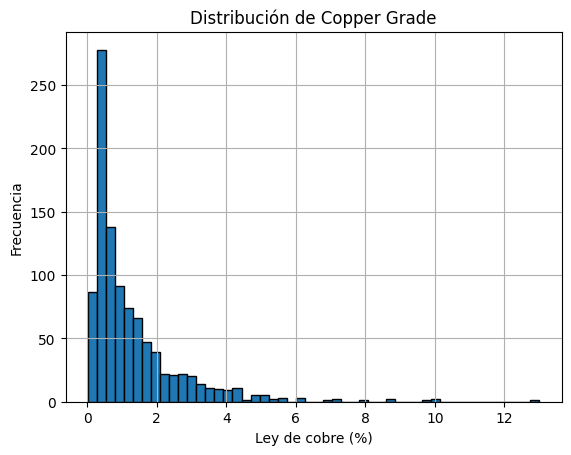

In [8]:
import matplotlib.pyplot as plt

df_cu["Copper_grade(Cu; %)"].hist(bins=50, edgecolor="black")
plt.xlabel("Ley de cobre (%)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Copper Grade")
plt.show()

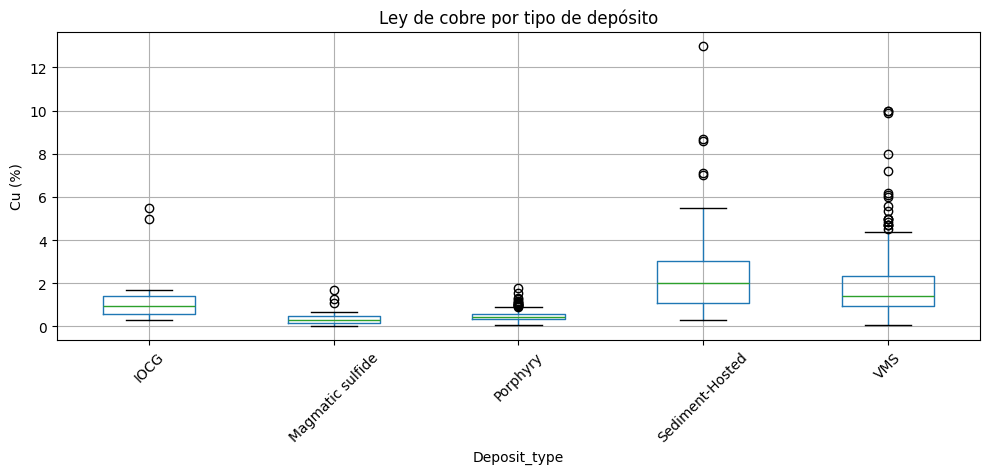

In [9]:
df_cu.boxplot(column="Copper_grade(Cu; %)", by="Deposit_type", figsize=(10, 5))
plt.suptitle("")
plt.title("Ley de cobre por tipo de depósito")
plt.ylabel("Cu (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Preparación para modelado

Definir features, target y encodear `Deposit_type` (variable categórica) a números.

In [10]:
features = ["Latitude", "Longitude", "Tonnage(Mt)", "Max_age(Ma)", "Min_age(Ma)"]
target = "Copper_grade(Cu; %)"

In [11]:
df_model = df_cu[features + [target, "Deposit_type"]].copy()
print(f"Registros: {len(df_model)}")
print(f"Nulos por columna:")
print(df_model.isnull().sum())

Registros: 989
Nulos por columna:
Latitude                 0
Longitude                0
Tonnage(Mt)              8
Max_age(Ma)            173
Min_age(Ma)            173
Copper_grade(Cu; %)      0
Deposit_type             0
dtype: int64


In [12]:
df_model = pd.get_dummies(df_model, columns=["Deposit_type"], prefix="type")
df_model.head()

,Latitude,Longitude,Tonnage(Mt),Max_age(Ma),Min_age(Ma),Copper_grade(Cu; %),type_IOCG,type_Magmatic sulfide,type_Porphyry,type_Sediment-Hosted,type_VMS
0,-22.289444,-68.901111,21277.0,35.07,31.0,0.592,False,False,True,False,False
1,40.533056,8.334167,189.0,34.00,27.0,0.070,False,False,True,False,False
2,30.320611,-109.564934,1800.0,54.20,53.4,0.452,False,False,True,False,False
3,44.737778,21.702500,500.0,73.10,65.0,0.350,False,False,True,False,False
4,33.058333,-110.745833,48.1,64.00,63.0,1.100,False,False,True,False,False


## 6.5 Feature engineering: minerales presentes

La columna `Mineral_assemblage` lista los minerales de cada depósito como string separado por comas. Vamos a convertirla en features binarias (una columna por mineral). Los minerales cobre-portantes (chalcopirita, bornita, calcosina, etc.) son predictores directos de la ley de Cu.

In [13]:
from collections import Counter

all_minerals = []
for s in df_cu["Mineral_assemblage"].dropna():
    all_minerals.extend([m.strip() for m in s.split(",")])

mineral_counts = Counter(all_minerals)
print(f"Minerales únicos en el dataset: {len(mineral_counts)}")
print(f"\nTop 20 más frecuentes:")
for mineral, count in mineral_counts.most_common(20):
    pct = 100 * count / len(df_cu)
    print(f"  {mineral:20s}  {count:4d}  ({pct:.1f}% de los depósitos)")

Minerales únicos en el dataset: 1011

Top 20 más frecuentes:
  Pyrite                 881  (89.1% de los depósitos)
  Chalcopyrite           873  (88.3% de los depósitos)
  Sphalerite             624  (63.1% de los depósitos)
  Muscovite              583  (58.9% de los depósitos)
  Quartz                 551  (55.7% de los depósitos)
  Galena                 534  (54.0% de los depósitos)
  Bornite                515  (52.1% de los depósitos)
  Magnetite              515  (52.1% de los depósitos)
  Chalcocite             458  (46.3% de los depósitos)
  Hematite               415  (42.0% de los depósitos)
  Pyrrhotite             407  (41.2% de los depósitos)
  Epidote                401  (40.5% de los depósitos)
  Molybdenite            401  (40.5% de los depósitos)
  Calcite                383  (38.7% de los depósitos)
  Malachite              382  (38.6% de los depósitos)
  Covellite              376  (38.0% de los depósitos)
  Gold                   361  (36.5% de los depósitos)
  Az

In [14]:
TOP_N = 50
top_minerals = [m for m, _ in mineral_counts.most_common(TOP_N)]

minerals_set = df_cu.loc[df_model.index, "Mineral_assemblage"].apply(
    lambda s: set(m.strip() for m in s.split(",")) if pd.notna(s) else set()
)

for mineral in top_minerals:
    col_name = f"has_{mineral.lower().replace(' ', '_').replace('-', '_')}"
    df_model[col_name] = minerals_set.apply(lambda s: int(mineral in s))

print(f"Agregadas {len(top_minerals)} features binarias de minerales")
print(f"Shape de df_model: {df_model.shape}")
print(f"\nEjemplo de las primeras 5 columnas nuevas:")
print(df_model[[f'has_{m.lower().replace(" ", "_").replace("-", "_")}' for m in top_minerals[:5]]].head())

Agregadas 50 features binarias de minerales
Shape de df_model: (989, 61)

Ejemplo de las primeras 5 columnas nuevas:
   has_pyrite  has_chalcopyrite  has_sphalerite  has_muscovite  has_quartz
0           1                 1               1              1           1
1           1                 1               1              1           1
2           1                 1               1              1           1
3           1                 1               1              1           0
4           1                 1               1              1           1


## 7. Entrenamiento y validación

Separamos el dataset en tres: **train** (para entrenar), **val** (para iterar sobre hiperparámetros y features) y **test** (intocable hasta el final). Usamos cross-validation sobre training para métricas estables.

### 7.1 Split train / val / test

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

feature_cols = ["Latitude", "Longitude", "Tonnage(Mt)", "Max_age(Ma)", "Min_age(Ma)"] + \
               [c for c in df_model.columns if c.startswith("type_")] + \
               [c for c in df_model.columns if c.startswith("has_")]

X = df_model[feature_cols]
y = df_model["Copper_grade(Cu; %)"]
y_log = np.log1p(y)

# 1) Reservamos el test set (20%) — NO se toca hasta la evaluación final
X_temp, X_test, y_temp_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 2) Del resto: 80% train / 20% val (equivale a 64/16 del total)
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X_temp, y_temp_log, test_size=0.2, random_state=42
)

y_train = np.expm1(y_train_log)
y_val = np.expm1(y_val_log)
y_test = np.expm1(y_test_log)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}  (INTOCABLE hasta el final)")
print(f"Total features: {len(feature_cols)}")

Train: (632, 60)
Val:   (159, 60)
Test:  (198, 60)  (INTOCABLE hasta el final)
Total features: 60


### 7.2 Cross-validation sobre training

En lugar de confiar en un solo split, hacemos **5-fold CV** sobre el training set. Si los 5 folds dan R² similares, el modelo es estable; si varían mucho, estamos viendo ruido. Las métricas se reportan en la escala original (% Cu), no en log.

In [16]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Scorers custom que reciben y_log y comparan en escala original
def rmse_original(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log)))

def r2_original(y_true_log, y_pred_log):
    return r2_score(np.expm1(y_true_log), np.expm1(y_pred_log))

rmse_scorer = make_scorer(rmse_original, greater_is_better=False)
r2_scorer = make_scorer(r2_original, greater_is_better=True)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)

r2_scores = cross_val_score(cv_model, X_train, y_train_log, cv=kf, scoring=r2_scorer)
rmse_scores = -cross_val_score(cv_model, X_train, y_train_log, cv=kf, scoring=rmse_scorer)

print(f"R² por fold:    {r2_scores.round(3)}")
print(f"R² promedio:    {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")
print(f"\nRMSE por fold:  {rmse_scores.round(3)}")
print(f"RMSE promedio:  {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")

R² por fold:    [0.632 0.316 0.451 0.394 0.401]
R² promedio:    0.439 ± 0.106

RMSE por fold:  [0.768 1.018 1.106 1.005 1.138]
RMSE promedio:  1.007 ± 0.130


### 7.3 Entrenamiento final

Una vez que estamos conformes con las métricas de CV, entrenamos el modelo final sobre `train + val` combinados. Ese es el modelo que va a predecir sobre test en la sección 8.

In [17]:
from xgboost import XGBRegressor
import pandas as pd

# Para el modelo final entrenamos sobre train + val combinados (más datos = mejor modelo)
X_train_full = pd.concat([X_train, X_val])
y_train_full_log = pd.concat([y_train_log, y_val_log])

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train_full, y_train_full_log)
print(f"Modelo final entrenado con {len(X_train_full)} muestras (train + val)")

Modelo final entrenado con 791 muestras (train + val)


## 8. Evaluación del modelo

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

RMSE: 1.129
MAE:  0.574
R²:   0.368


## 9. Feature importance

¿Qué features está usando el modelo realmente? Si el top de importance está dominado por minerales cobre-portantes (chalcopyrite, bornite, etc.) es señal de que aprendió lógica real. Si está dominado por minerales no-cobre o por lat/lon, estamos capturando ruido o patrones geográficos que no generalizan.

In [19]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("Top 20 features más importantes:")
for feat, imp in importances.head(20).items():
    print(f"  {feat:35s}  {imp:.4f}")

print(f"\nSuma importancias top 20: {importances.head(20).sum():.3f}")
print(f"Suma importancias total:  {importances.sum():.3f}")

Top 20 features más importantes:
  type_Porphyry                        0.4600
  type_Magmatic sulfide                0.1624
  type_Sediment-Hosted                 0.0290
  has_chrysocolla                      0.0215
  has_azurite                          0.0211
  type_VMS                             0.0186
  type_IOCG                            0.0143
  has_talc                             0.0115
  has_brochantite                      0.0104
  Tonnage(Mt)                          0.0104
  has_hessite                          0.0093
  has_rutile                           0.0087
  has_malachite                        0.0084
  has_tremolite                        0.0082
  has_pyrrhotite                       0.0080
  has_molybdenite                      0.0078
  has_siderite                         0.0074
  has_magnetite                        0.0069
  has_albite                           0.0066
  Latitude                             0.0061

Suma importancias top 20: 0.837
Suma importanc

## 10. Optimización del modelo

El CV nos mostró R² = 0.44 ± 0.11 — alta varianza = overfitting. Con 791 filas de train y 60+ features, estamos sobreajustados. Tres acciones:

1. **Seleccionar features**: quedarnos solo con las que el modelo usa (importance > umbral).
2. **Búsqueda de hiperparámetros**: `RandomizedSearchCV` con regularización (`reg_alpha`, `reg_lambda`, `min_child_weight`).
3. **Re-evaluar**: el R² nuevo debería subir y la std bajar.

### 10.1 Selección de features

In [20]:
IMPORTANCE_THRESHOLD = 0.003
selected_features = importances[importances > IMPORTANCE_THRESHOLD].index.tolist()

print(f"Features originales:   {len(feature_cols)}")
print(f"Features seleccionadas: {len(selected_features)} (importance > {IMPORTANCE_THRESHOLD})")
print(f"\nFeatures descartadas: {len(feature_cols) - len(selected_features)}")

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]

Features originales:   60
Features seleccionadas: 54 (importance > 0.003)

Features descartadas: 6


### 10.2 Búsqueda de hiperparámetros (RandomizedSearchCV)

Probamos 40 combinaciones aleatorias sobre el training set con 5-fold CV. Las variables clave son las de regularización:
- `reg_alpha` (L1): fuerza pesos a cero — reduce features efectivas.
- `reg_lambda` (L2): reduce magnitud de todos los pesos.
- `min_child_weight`: mínimo número de muestras por hoja, evita árboles que memorizan pocas filas.
- `max_depth`: profundidad máxima; más bajo = menos overfitting.

In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [1, 3, 5, 10],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=40,
    cv=kf,
    scoring=r2_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train_sel, y_train_log)

print(f"Mejor R² CV:       {search.best_score_:.3f}")
print(f"Baseline anterior: 0.439 ± 0.106")
print(f"\nMejores hiperparámetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Mejor R² CV:       0.447
Baseline anterior: 0.439 ± 0.106

Mejores hiperparámetros:
  subsample: 0.7
  reg_lambda: 1
  reg_alpha: 0.1
  n_estimators: 300
  min_child_weight: 1
  max_depth: 6
  learning_rate: 0.1
  colsample_bytree: 0.7


### 10.3 Validación cruzada del modelo optimizado

Antes de tocar el test, verificamos que el nuevo modelo tiene CV estable (menor std).

In [22]:
best_model = XGBRegressor(**search.best_params_, random_state=42)

r2_opt = cross_val_score(best_model, X_train_sel, y_train_log, cv=kf, scoring=r2_scorer)
rmse_opt = -cross_val_score(best_model, X_train_sel, y_train_log, cv=kf, scoring=rmse_scorer)

print(f"R² por fold:    {r2_opt.round(3)}")
print(f"R² promedio:    {r2_opt.mean():.3f} ± {r2_opt.std():.3f}")
print(f"\nRMSE por fold:  {rmse_opt.round(3)}")
print(f"RMSE promedio:  {rmse_opt.mean():.3f} ± {rmse_opt.std():.3f}")

print(f"\n--- Comparación ---")
print(f"Baseline:  R² = 0.439 ± 0.106, RMSE = 1.007 ± 0.130")
print(f"Optimiz.:  R² = {r2_opt.mean():.3f} ± {r2_opt.std():.3f}, RMSE = {rmse_opt.mean():.3f} ± {rmse_opt.std():.3f}")

R² por fold:    [0.629 0.28  0.47  0.412 0.445]
R² promedio:    0.447 ± 0.112

RMSE por fold:  [0.771 1.045 1.086 0.989 1.095]
RMSE promedio:  0.997 ± 0.119

--- Comparación ---
Baseline:  R² = 0.439 ± 0.106, RMSE = 1.007 ± 0.130
Optimiz.:  R² = 0.447 ± 0.112, RMSE = 0.997 ± 0.119
